In [ ]:
import pandas as pd

In [ ]:
# Instala a biblioteca do Kaggle Hub de forma silenciosa
%pip -q install kagglehub

import kagglehub
from pathlib import Path

# Baixa os 12 arquivos mensais do dataset do Kaggle para uma pasta local
pasta = Path(kagglehub.dataset_download("saviovianna/queimadas-inpe"))
arquivos = sorted(pasta.glob("qi_??_2024.csv"))

if len(arquivos) != 12:
    raise FileNotFoundError(f"Esperados 12 CSVs de 2024; encontrados {len(arquivos)}: {[a.name for a in arquivos]}")

print(f"Dataset descarregado com sucesso na pasta: {pasta}")

Using Colab cache for faster access to the 'queimadas-inpe' dataset.
Dataset descarregado com sucesso na pasta: /kaggle/input/queimadas-inpe


In [ ]:
import pandas as pd
from pathlib import Path
import kagglehub

# Carrega apenas o cabeçalho do primeiro arquivo para ver os nomes das colunas
pasta = Path(kagglehub.dataset_download("saviovianna/queimadas-inpe"))
primeiro_arquivo = sorted(pasta.glob("qi_??_2024.csv"))[0]
df_colunas = pd.read_csv(primeiro_arquivo, nrows=0)

print("Colunas disponíveis no dataset:")
print(list(df_colunas.columns))

Using Colab cache for faster access to the 'queimadas-inpe' dataset.
Colunas disponíveis no dataset:
['id', 'lat', 'lon', 'data_hora_gmt', 'satelite', 'municipio', 'estado', 'pais', 'municipio_id', 'estado_id', 'pais_id', 'numero_dias_sem_chuva', 'precipitacao', 'risco_fogo', 'bioma', 'frp', 'quantidade_ocorrencias', 'temperatura', 'cobertura_nuvens', 'ponto_orvalho_2m', 'pressao_msl', 'radiacao_direta', 'radiacao_ondas_curtas', 'umidade_solo_0_a_7cm', 'temperatura_solo_0_a_7cm', 'rajadas_vento_10m']


In [ ]:
import pandas as pd

# Define as colunas que queres ler (podes adicionar as novas métricas aqui se existirem no CSV)
colunas = [
    "lat", "lon", "data_hora_gmt", "municipio", "estado",
    "risco_fogo", "bioma", "temperatura", "ponto_orvalho_2m",
    "numero_dias_sem_chuva", "rajadas_vento_10m","pressao_msl"
]

partes = []
for arquivo in arquivos:
    # Lê apenas as colunas necessárias para poupar memória RAM no Colab
    parte = pd.read_csv(arquivo, usecols=colunas)
    print(f"Lido: {arquivo.name} com {len(parte)} registos")
    partes.append(parte)

# Junta todos os meses num único DataFrame gigante
df = pd.concat(partes, ignore_index=True)
del partes # Limpa a memória RAM

# Converte a coluna de data para o formato datetime
df["data_hora_gmt"] = pd.to_datetime(df["data_hora_gmt"], errors="coerce")

print("\n--- Resumo dos Dados Carregados ---")
print(f"Total de registos em 2024: {len(df):,}")
print(f"Período: {df['data_hora_gmt'].min()} até {df['data_hora_gmt'].max()}")

# Mostra as primeiras linhas para validação
df.head()

Lido: qi_01_2024.csv com 88120 registos
Lido: qi_02_2024.csv com 73315 registos
Lido: qi_03_2024.csv com 60176 registos
Lido: qi_04_2024.csv com 27477 registos
Lido: qi_05_2024.csv com 75364 registos
Lido: qi_06_2024.csv com 153672 registos
Lido: qi_07_2024.csv com 225374 registos
Lido: qi_08_2024.csv com 596641 registos
Lido: qi_09_2024.csv com 1081937 registos
Lido: qi_10_2024.csv com 479794 registos
Lido: qi_11_2024.csv com 258626 registos
Lido: qi_12_2024.csv com 127537 registos

--- Resumo dos Dados Carregados ---
Total de registos em 2024: 3,248,033
Período: 2024-01-01 00:00:00 até 2024-12-31 23:00:00


,lat,lon,data_hora_gmt,municipio,estado,numero_dias_sem_chuva,risco_fogo,bioma,temperatura,ponto_orvalho_2m,pressao_msl,rajadas_vento_10m
0,-12.5667,-41.4364,2024-01-01 00:00:00,LENÇÓIS,BAHIA,8.0,0.70,Caatinga,26.0,18.0,1012.8,13.3
1,-12.5662,-41.4611,2024-01-01 00:00:00,LENÇÓIS,BAHIA,9.0,0.83,Caatinga,26.0,18.0,1012.8,13.3
2,-18.0629,-57.3721,2024-01-01 00:00:00,CORUMBÁ,MATO GROSSO DO SUL,0.0,0.00,Pantanal,30.0,23.6,1009.1,9.4
3,-18.0625,-57.3927,2024-01-01 00:00:00,CORUMBÁ,MATO GROSSO DO SUL,0.0,0.01,Pantanal,29.8,24.1,1009.2,10.4
4,-18.0629,-57.3721,2024-01-01 01:00:00,CORUMBÁ,MATO GROSSO DO SUL,0.0,0.00,Pantanal,29.6,24.0,1009.8,9.4


In [ ]:
df.columns

Index(['lat', 'lon', 'data_hora_gmt', 'municipio', 'estado',
       'numero_dias_sem_chuva', 'risco_fogo', 'bioma', 'temperatura',
       'ponto_orvalho_2m', 'pressao_msl', 'rajadas_vento_10m'],
      dtype='object')

In [ ]:
import numpy as np

# Temperatura do ar e ponto de orvalho em graus Celsius.
t = pd.to_numeric(df["temperatura"], errors="coerce")
td = pd.to_numeric(df["ponto_orvalho_2m"], errors="coerce")
validos = t.notna() & td.notna() & (td <= t)

# Fórmula de Magnus: umidade relativa do ar em porcentagem.
umidade_calculada = 100 * np.exp(
    (17.625 * td / (243.04 + td))
    - (17.625 * t / (243.04 + t))
)
df["umidade_ar_pct"] = umidade_calculada.where(validos).clip(0, 100)

print("Linhas:", len(df))
print("Umidade calculada:", df["umidade_ar_pct"].notna().sum())
print("Temperatura ou ponto de orvalho ausente:", (t.isna() | td.isna()).sum())
print("Ponto de orvalho acima da temperatura:", (t.notna() & td.notna() & (td > t)).sum())
display(df[["temperatura", "ponto_orvalho_2m", "umidade_ar_pct"]].head(10).round(1))

Linhas: 3248033
Umidade calculada: 2938392
Temperatura ou ponto de orvalho ausente: 309641
Ponto de orvalho acima da temperatura: 0


,temperatura,ponto_orvalho_2m,umidade_ar_pct
0,26.0,18.0,61.4
1,26.0,18.0,61.4
2,30.0,23.6,68.6
3,29.8,24.1,71.5
4,29.6,24.0,71.9
5,29.5,24.1,72.8
6,26.8,17.1,55.3
7,24.1,20.5,80.3
8,26.4,19.1,64.2
9,24.1,22.2,89.1


In [ ]:
# Os 12 CSVs reunidos cobrem todo o ano de 2024.
print("Período:", df["data_hora_gmt"].min(), "a", df["data_hora_gmt"].max())
print("Registros no arquivo:", len(df))

# Contagem pelo nome do município informado no dataset.
sao_joao = df[df["municipio"].astype(str).str.contains("JOÃO DA BOA VISTA", case=False, na=False)]
print("Registros em São João da Boa Vista:", len(sao_joao))

# Distância até o ponto central da Serra usado no notebook anterior.
lat_centro, lon_centro = -21.947818246740198, -46.78653641223045
lat = np.radians(pd.to_numeric(df["lat"], errors="coerce"))
lon = np.radians(pd.to_numeric(df["lon"], errors="coerce"))
lat0, lon0 = np.radians(lat_centro), np.radians(lon_centro)
a = np.sin((lat - lat0) / 2)**2 + np.cos(lat0) * np.cos(lat) * np.sin((lon - lon0) / 2)**2
distancia_km = 6371 * 2 * np.arcsin(np.sqrt(a.clip(0, 1)))

perto_5km = df[distancia_km <= 5]
perto_10km = df[distancia_km <= 10]
print("Registros até 5 km do ponto central:", len(perto_5km))
print("Registros até 10 km do ponto central:", len(perto_10km))
display(perto_10km[["data_hora_gmt", "municipio", "lat", "lon", "temperatura", "umidade_ar_pct"]].head(10))

Período: 2024-01-01 00:00:00 a 2024-12-31 23:00:00
Registros no arquivo: 3248033
Registros em São João da Boa Vista: 103
Registros até 5 km do ponto central: 20
Registros até 10 km do ponto central: 100


,data_hora_gmt,municipio,lat,lon,temperatura,umidade_ar_pct
230862,2024-04-11 17:00:00,SÃO JOÃO DA BOA VISTA,-21.99773,-46.802350,29.1,54.175967
239536,2024-04-23 17:00:00,SÃO JOÃO DA BOA VISTA,-22.01036,-46.774740,28.9,31.041293
262217,2024-05-07 16:00:00,SÃO JOÃO DA BOA VISTA,-21.98989,-46.768415,28.9,47.115064
293667,2024-05-19 16:00:00,ÁGUAS DA PRATA,-21.96388,-46.706170,27.2,44.595802
296619,2024-05-21 04:00:00,SÃO JOÃO DA BOA VISTA,-22.01409,-46.829400,17.2,84.695400
349154,2024-06-08 04:00:00,SÃO JOÃO DA BOA VISTA,-21.98126,-46.824680,12.6,90.583328
349155,2024-06-08 04:00:00,SÃO JOÃO DA BOA VISTA,-21.98429,-46.826660,12.6,90.583328
363100,2024-06-11 16:00:00,SÃO JOÃO DA BOA VISTA,-21.98455,-46.826030,26.5,35.715132
381784,2024-06-14 16:00:00,SÃO JOÃO DA BOA VISTA,-21.98741,-46.762260,25.8,39.002215
382658,2024-06-14 17:00:00,SÃO JOÃO DA BOA VISTA,-21.98783,-46.758110,26.4,36.653291


In [ ]:
# Focos registrados em Cerrado ou Mata Atlântica (dados de todo o ano de 2024).
df_biomas = df[df["bioma"].astype(str).str.contains("CERRADO|MATA ATL", case=False, na=False)].copy()

print("Registros dos dois biomas:", len(df_biomas))
print("Por bioma:")
print(df_biomas["bioma"].value_counts())
print("Desses, no estado de São Paulo:", len(df_biomas[df_biomas["estado"] == "SÃO PAULO"]))
display(df_biomas[["data_hora_gmt", "bioma", "estado", "municipio", "temperatura", "umidade_ar_pct"]].head())

Registros dos dois biomas: 1152595
Por bioma:
bioma
Cerrado           944155
Mata Atlântica    208440
Name: count, dtype: int64
Desses, no estado de São Paulo: 73467


,data_hora_gmt,bioma,estado,municipio,temperatura,umidade_ar_pct
10,2024-01-01 03:00:00,Mata Atlântica,PERNAMBUCO,SIRINHAÉM,26.6,82.629974
11,2024-01-01 04:00:00,Mata Atlântica,BAHIA,SANTA CRUZ CABRÁLIA,24.4,89.714979
12,2024-01-01 04:00:00,Mata Atlântica,BAHIA,SANTA CRUZ CABRÁLIA,24.4,89.714979
13,2024-01-01 04:00:00,Mata Atlântica,BAHIA,CANAVIEIRAS,25.2,87.629167
14,2024-01-01 04:00:00,Mata Atlântica,BAHIA,SANTA LUZIA,23.8,89.671004


In [ ]:
# Alvo y: índice de risco de fogo já calculado no dataset (escala de 0 a 1).
risco = pd.to_numeric(df_biomas["risco_fogo"], errors="coerce")
dados_risco = df_biomas.loc[risco.between(0, 1)].copy()
dados_risco["y_risco_fogo"] = risco.loc[dados_risco.index]

print("Registros dos biomas:", len(df_biomas))
print("Risco válido (0 a 1):", len(dados_risco))
print("Risco ausente ou inválido:", len(df_biomas) - len(dados_risco))
print("Resumo do y:")
print(dados_risco["y_risco_fogo"].describe().round(3))
display(dados_risco[["bioma", "temperatura", "umidade_ar_pct", "y_risco_fogo"]].head(10))

Registros dos biomas: 1152595
Risco válido (0 a 1): 1152595
Risco ausente ou inválido: 0
Resumo do y:
count    1152595.000
mean           0.863
std            0.294
min            0.000
25%            0.970
50%            1.000
75%            1.000
max            1.000
Name: y_risco_fogo, dtype: float64


,bioma,temperatura,umidade_ar_pct,y_risco_fogo
10,Mata Atlântica,26.6,82.629974,1.0000
11,Mata Atlântica,24.4,89.714979,0.4125
12,Mata Atlântica,24.4,89.714979,0.5900
13,Mata Atlântica,25.2,87.629167,0.3400
14,Mata Atlântica,23.8,89.671004,0.7400
15,Mata Atlântica,24.7,82.910121,0.4500
16,Cerrado,22.7,89.040268,0.0000
17,Mata Atlântica,25.1,86.041024,0.1600
18,Mata Atlântica,23.5,90.198297,0.1700
29,Mata Atlântica,25.1,85.520104,0.2700


In [ ]:
dados_risco

In [ ]:
import numpy as np

# Mantém somente linhas que possuem os dados essenciais para o Arduino e para as novas métricas
dados_risco = df.dropna(
    subset=["temperatura", "ponto_orvalho_2m", "numero_dias_sem_chuva", "rajadas_vento_10m", "data_hora_gmt"]
).copy()

# O mês continua a ser útil para dar noção de sazonalidade sem precisar de sensor extra
dados_risco["mes"] = dados_risco["data_hora_gmt"].dt.month
dados_risco["mes_sen"] = np.sin(2 * np.pi * dados_risco["mes"] / 12)
dados_risco["mes_cos"] = np.cos(2 * np.pi * dados_risco["mes"] / 12)

# Transforma os biomas em códigos numéricos limpos (ex: Amazônia, Cerrado, Mata Atlântica, etc.)
dados_risco["bioma_codigo"] = dados_risco["bioma"].astype("category").cat.codes

# Define as features finais combinando as métricas do Arduino, sazonalidade e o bioma unificado
X = dados_risco[[
    "temperatura",
    "numero_dias_sem_chuva",
    "rajadas_vento_10m",
    "umidade_ar_pct",
    "bioma_codigo",
    "pressao_msl"
]].copy()

y = dados_risco["risco_fogo"]

print("Registros prontos para modelar:", len(X))

Registros prontos para modelar: 2938392


In [ ]:
X

,temperatura,numero_dias_sem_chuva,rajadas_vento_10m,umidade_ar_pct,bioma_codigo,pressao_msl
0,26.0,8.0,13.3,61.388520,1,1012.8
1,26.0,9.0,13.3,61.388520,1,1012.8
2,30.0,0.0,9.4,68.621729,5,1009.1
3,29.8,0.0,10.4,71.534362,5,1009.2
4,29.6,0.0,9.4,71.929769,5,1009.8
...,...,...,...,...,...,...
3248028,32.9,2.0,14.0,56.120396,0,1007.8
3248029,31.8,2.0,20.2,58.998754,0,1008.4
3248030,28.5,0.0,22.0,77.118382,0,1007.9
3248031,26.6,12.0,29.9,80.169695,1,1012.1


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.25)

# Treinanando modelos de regressão : DecisionTree, Mlp, GradientBoost

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score



In [ ]:
arvore_modelo = DecisionTreeRegressor(max_depth=8, min_samples_leaf=200, random_state=42)

arvore_modelo.fit(X_train, y_train)
pred_arvore = arvore_modelo.predict(X_test)
print("MAE", mean_absolute_error(y_test, pred_arvore))
print("R²: ", r2_score(y_test, pred_arvore) )


MAE 0.14840075715956114
R²:  0.4723590937906026


In [ ]:
gradient_Boost = HistGradientBoostingRegressor(max_iter=100, max_leaf_nodes=15, min_samples_leaf=100, random_state=42)

gradient_Boost.fit(X_train, y_train)
pred_gradient_Boost = gradient_Boost.predict(X_test)
print("MAE", mean_absolute_error(y_test, pred_gradient_Boost))
print("R²: ", r2_score(y_test, pred_gradient_Boost) )

MAE 0.14414697242176647
R²:  0.5155010237488569


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Criar o Pipeline juntando a padronização e a Rede Neural
pipeline_mlp = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo', MLPRegressor(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        alpha = 0.01,
        max_iter=1000,
        learning_rate_init =  0.001,
        random_state=42,
        early_stopping=True
    ))
])
# 2. Treinar o modelo com os seus dados de treino
pipeline_mlp.fit(X_train, y_train)

# 3. Fazer as previsões no conjunto de teste
previsoes_mlp = pipeline_mlp.predict(X_test)

# 4. Avaliar o desempenho
mse_mlp = mean_squared_error(y_test, previsoes_mlp)
mae_mlp = mean_absolute_error(y_test, previsoes_mlp)
r2_mlp = r2_score(y_test, previsoes_mlp)

print(f"Erro Quadrático Médio (MSE) - MLP: {mse_mlp:.4f}")
print(f"Erro Absoluto Médio (MAE) - MLP: {mae_mlp:.4f}")
print(f"R² (Coeficiente de Determinação) - MLP: {r2_mlp:.4f}")

Erro Quadrático Médio (MSE) - MLP: 0.0455
Erro Absoluto Médio (MAE) - MLP: 0.1389
R² (Coeficiente de Determinação) - MLP: 0.5362


rro Quadrático Médio (MSE) - MLP: 0.0393
Erro Absoluto Médio (MAE) - MLP: 0.1092
R² (Coeficiente de Determinação) - MLP: 0.5773

# Aplicando tecnicas de melhorias

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Espaço de parâmetros para a Árvore
param_arvore = {
    'max_depth': [3, 5, 8, 10, 15, None],
    'min_samples_leaf': [10, 50, 100, 200],
    'min_samples_split': [10, 50, 100, 200]
}

# Configuração da busca aleatória
random_arvore = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions=param_arvore,
    n_iter=10,  #
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42
)

# Treinamento
random_arvore.fit(X_train, y_train)
melhor_arvore = random_arvore.best_estimator_

# Previsão e Avaliação
pred_arvore = melhor_arvore.predict(X_test)
print("--- Árvore de Decisão Otimizada ---")
print("Melhores parâmetros:", random_arvore.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_arvore))
print("R²: ", r2_score(y_test, pred_arvore))

--- Árvore de Decisão Otimizada ---
Melhores parâmetros: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': None}
MAE: 0.09705328371397212
R²:  0.6477908153165375


--- Árvore de Decisão Otimizada ---
Melhores parâmetros: {'min_samples_split': 10, 'min_samples_leaf': 10, 'max_depth': None}
MAE: 0.10992662668776192
R²:  0.5930501766743865

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Espaço de parâmetros para o Gradient Boosting
param_gb = {
    'max_iter': [50, 100, 150, 200],
    'max_leaf_nodes': [10, 15, 30, 50],
    'min_samples_leaf': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2]
}

# Configuração da busca aleatória
random_gb = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=42),
    param_distributions=param_gb,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42
)

# Treinamento
random_gb.fit(X_train, y_train)
melhor_gb = random_gb.best_estimator_

# Previsão e Avaliação
pred_gb = melhor_gb.predict(X_test)
print("--- Gradient Boosting Otimizado ---")
print("Melhores parâmetros:", random_gb.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_gb))
print("R²: ", r2_score(y_test, pred_gb))

--- Gradient Boosting Otimizado ---
Melhores parâmetros: {'min_samples_leaf': 50, 'max_leaf_nodes': 50, 'max_iter': 150, 'learning_rate': 0.2}
MAE: 0.13166169848995452
R²:  0.5634736658490784


-- Gradient Boosting Otimizado ---
Melhores parâmetros: {'min_samples_leaf': 50, 'max_leaf_nodes': 50, 'max_iter': 150, 'learning_rate': 0.2}
MAE: 0.10635364088200426
R²:  0.5876159182149123

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Espaço de parâmetros para a MLP (precisa usar o prefixo 'modelo__' por causa do Pipeline)
param_mlp = {
    'modelo__hidden_layer_sizes': [(32,), (64, 32), (100, 50)],
    'modelo__activation': ['relu', 'tanh'],
    'modelo__alpha': [0.0001, 0.001, 0.01],
    'modelo__learning_rate_init': [0.001, 0.01]
}

# Pipeline obrigatório para a MLP
pipeline_mlp = Pipeline([
    ('escalonador', StandardScaler()),
    ('modelo', MLPRegressor(max_iter=1000, random_state=42, early_stopping=True))
])

# Configuração da busca aleatória
random_mlp = RandomizedSearchCV(
    pipeline_mlp,
    param_distributions=param_mlp,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42
)

# Treinamento
random_mlp.fit(X_train, y_train)
melhor_mlp = random_mlp.best_estimator_

# Previsão e Avaliação
pred_mlp = melhor_mlp.predict(X_test)
print("--- Rede Neural (MLP) Otimizada ---")
print("Melhores parâmetros:", random_mlp.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_mlp))
print("R²: ", r2_score(y_test, pred_mlp))

--- Rede Neural (MLP) Otimizada ---
Melhores parâmetros: {'modelo__learning_rate_init': 0.001, 'modelo__hidden_layer_sizes': (100, 50), 'modelo__alpha': 0.01, 'modelo__activation': 'relu'}
MAE: 0.14710522900757214
R²:  0.49850034162466283


In [ ]:
X

,temperatura,numero_dias_sem_chuva,rajadas_vento_10m,umidade_ar_pct,bioma_codigo
0,26.0,8.0,13.3,61.388520,1
1,26.0,9.0,13.3,61.388520,1
2,30.0,0.0,9.4,68.621729,5
3,29.8,0.0,10.4,71.534362,5
4,29.6,0.0,9.4,71.929769,5
...,...,...,...,...,...
3248028,32.9,2.0,14.0,56.120396,0
3248029,31.8,2.0,20.2,58.998754,0
3248030,28.5,0.0,22.0,77.118382,0
3248031,26.6,12.0,29.9,80.169695,1


In [ ]:
print(df["bioma"].value_counts())

bioma
Amazônia          1690283
Cerrado            944155
Mata Atlântica     208440
Caatinga           206191
Pantanal           194848
Pampa                4116
Name: count, dtype: int64


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

# Configuração do modelo XGBoost com suporte a GPU
# (se por acaso a T4 do Colab der algum aviso com 'cuda', podes trocar por 'cuda:0')
xgb_model = XGBRegressor(
    random_state=42,
    device='cuda',          # <-- Aqui ativas a GPU!
    tree_method='hist'      # Método rápido otimizado para histogramas
)

# Espaço de parâmetros para otimizar (ajustado para o XGBoost)
param_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Configuração da busca aleatória (podes subir o n_iter para 10 ou 15, já que vai correr super rápido na GPU)
random_xgb = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_xgb,
    n_iter=10,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1   # Usa os recursos disponíveis
)

# Treinamento (agora com a potência máxima da GPU!)
print("A iniciar treino com XGBoost na GPU...")
random_xgb.fit(X_train, y_train)
melhor_xgb = random_xgb.best_estimator_

# Previsão e Avaliação
pred_xgb = melhor_xgb.predict(X_test)
print("\n--- XGBoost Otimizado com GPU ---")
print("Melhores parâmetros:", random_xgb.best_params_)
print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R²: ", r2_score(y_test, pred_xgb))

A iniciar treino com XGBoost na GPU...

--- XGBoost Otimizado com GPU ---
Melhores parâmetros: {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
MAE: 0.13683171087507143
R²:  0.5432935277283508


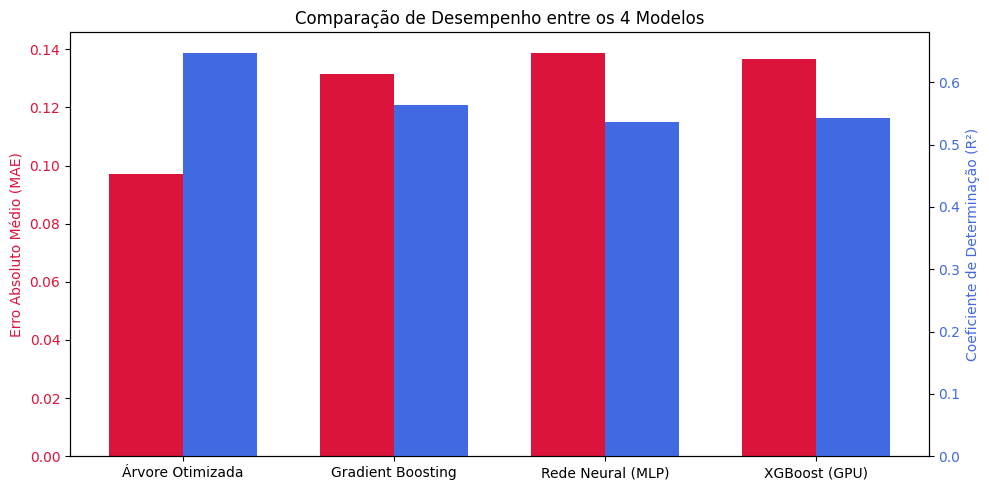


Todos os 4 modelos foram guardados com sucesso localmente!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import joblib

# 1. Recolher as previsões e métricas dos 4 modelos
modelos_nomes = ['Árvore Otimizada', 'Gradient Boosting', 'Rede Neural (MLP)', 'XGBoost (GPU)']

# Certifica-te de que tens as previsões guardadas (ou calcula-as agora)
preds = [
    melhor_arvore.predict(X_test),
    melhor_gb.predict(X_test),
    pipeline_mlp.predict(X_test), # Certifica-te que treinaste o pipeline_mlp com os parâmetros fixos
    melhor_xgb.predict(X_test)
]

maes = [mean_absolute_error(y_test, p) for p in preds]
r2s = [r2_score(y_test, p) for p in preds]

# 2. Criar o gráfico comparativo com os 4 modelos
fig, ax1 = plt.subplots(figsize=(10, 5))

x = np.arange(len(modelos_nomes))
width = 0.35

rects1 = ax1.bar(x - width/2, maes, width, label='MAE (Menor é melhor)', color='crimson')
ax1.set_ylabel('Erro Absoluto Médio (MAE)', color='crimson')
ax1.tick_params(axis='y', labelcolor='crimson')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos_nomes)

ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, r2s, width, label='R² (Maior é melhor)', color='royalblue')
ax2.set_ylabel('Coeficiente de Determinação (R²)', color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')

plt.title('Comparação de Desempenho entre os 4 Modelos')
fig.tight_layout()
plt.show()

# 3. Guardar os modelos em ficheiros locais (.pkl)
joblib.dump(melhor_arvore, 'modelo_arvore.pkl')
joblib.dump(melhor_gb, 'modelo_gradient_boosting.pkl')
joblib.dump(pipeline_mlp, 'modelo_mlp.pkl')
joblib.dump(melhor_xgb, 'modelo_xgboost.pkl')
print("\nTodos os 4 modelos foram guardados com sucesso localmente!")

# 4. Fazer o download automático dos ficheiros para o teu computador
from google.colab import files

files.download('modelo_arvore.pkl')
files.download('modelo_gradient_boosting.pkl')
files.download('modelo_mlp.pkl')
files.download('modelo_xgboost.pkl')